## Step 1: Import Required Libraries

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split ,cross_val_score , GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix ,classification_report

## Step 2: Load the Dataset

In [73]:
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df_copy = diabetes_df.copy()

## Step 3: Understand the Dataset

In [74]:
# First 5 rows
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [75]:
# Shape of dataset
print("\nShape of Dataset:", diabetes_df.shape)

# Column names
print("\nColumns in Dataset:\n")
print(diabetes_df.columns)

# Check missing values
print("\nMissing Values:\n")
print(diabetes_df.isna().sum())

# Target values
print("\nTarget Values:")
print(diabetes_df['Outcome'].value_counts())


Shape of Dataset: (768, 9)

Columns in Dataset:

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

Missing Values:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target Values:
Outcome
0    500
1    268
Name: count, dtype: int64


In [76]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [77]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [78]:
# check for duplicates
diabetes_df.duplicated().sum()

np.int64(0)

In [79]:
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']


## Step 4: EDA

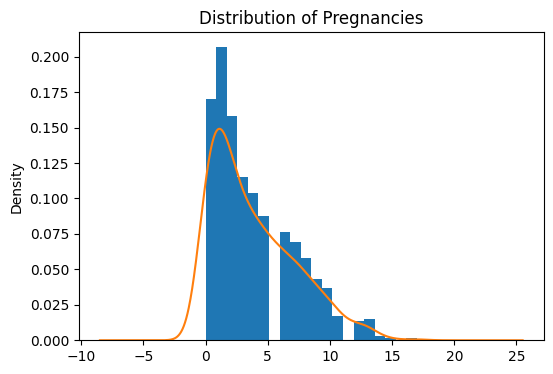

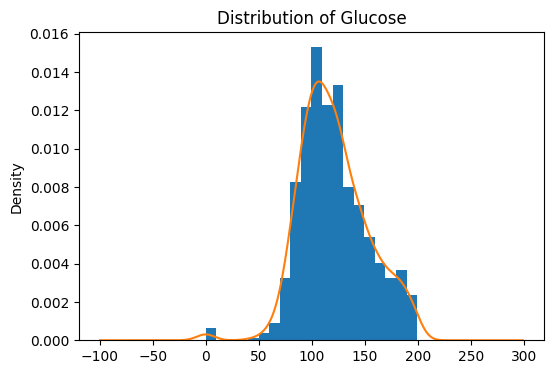

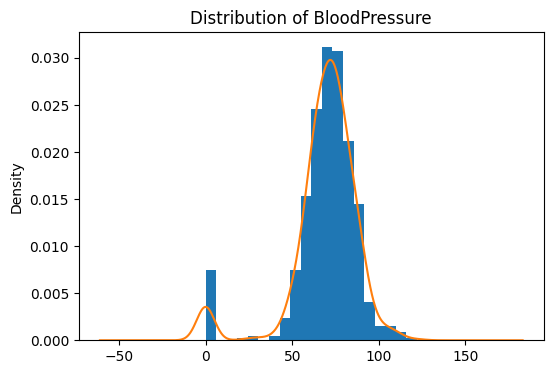

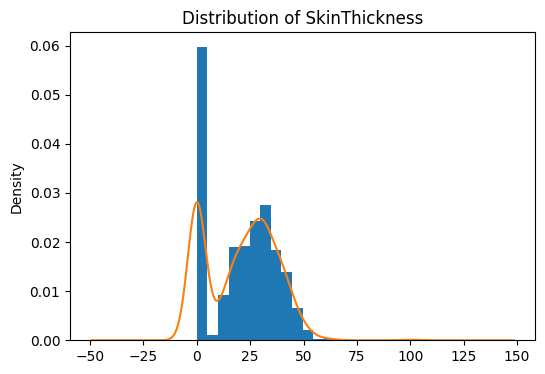

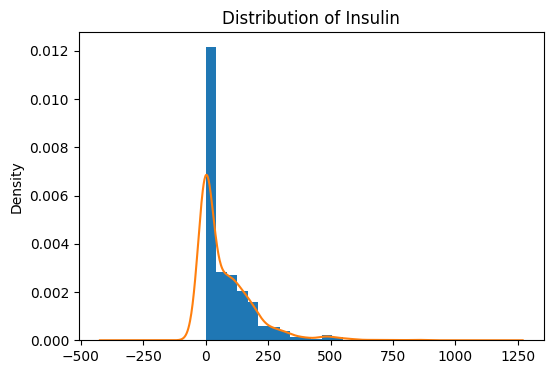

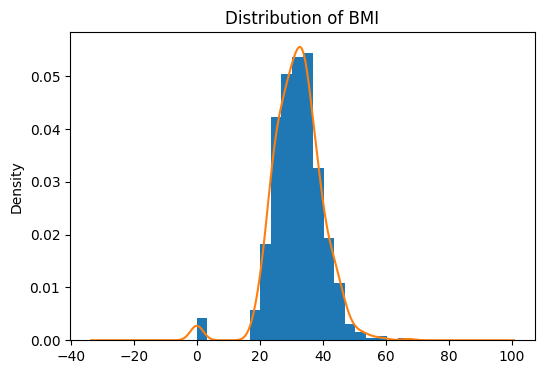

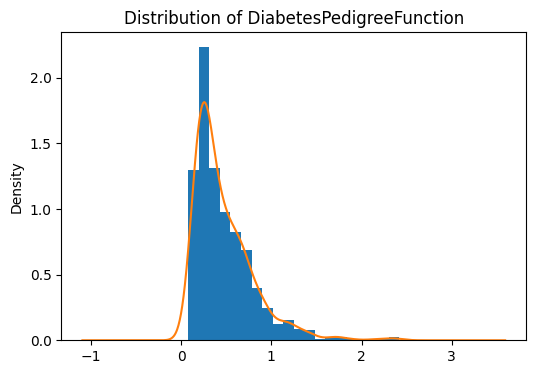

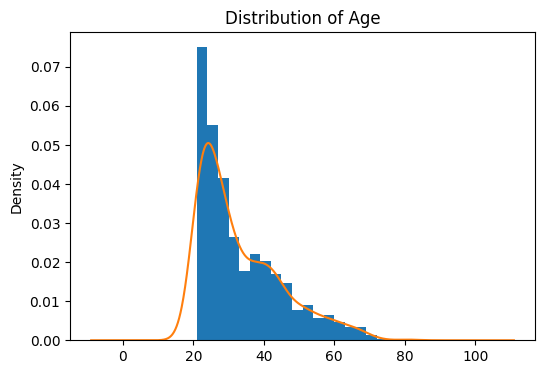

In [80]:
    # # since its a medical dataset , there will be missing values labelled with 0 
    # how to handle these missing values
    # check the distribution first

for col in col_names:
    
    plt.figure(figsize=(6,4))
    
    diabetes_df[col].plot(kind='hist', bins=20, density=True)
    diabetes_df[col].plot(kind='kde')
    
    plt.title(f'Distribution of {col}')
    plt.show()

Another way:

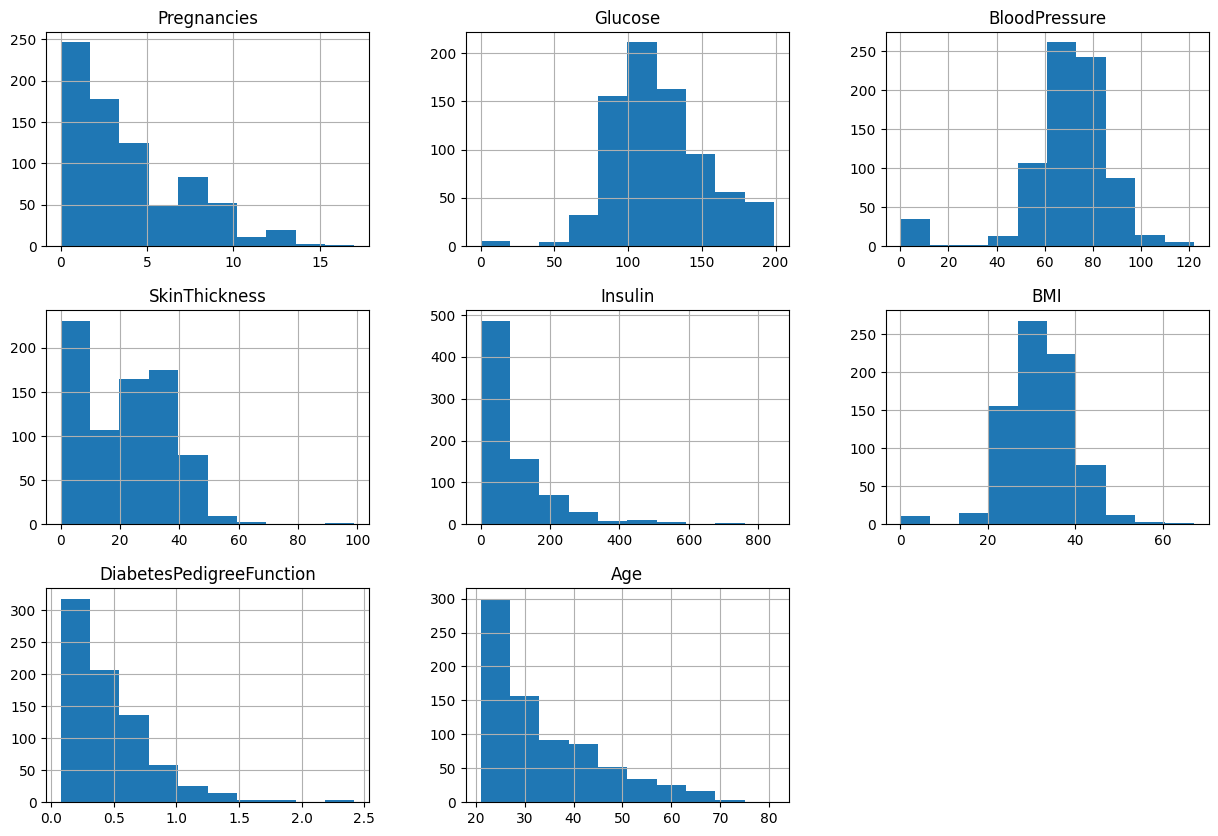

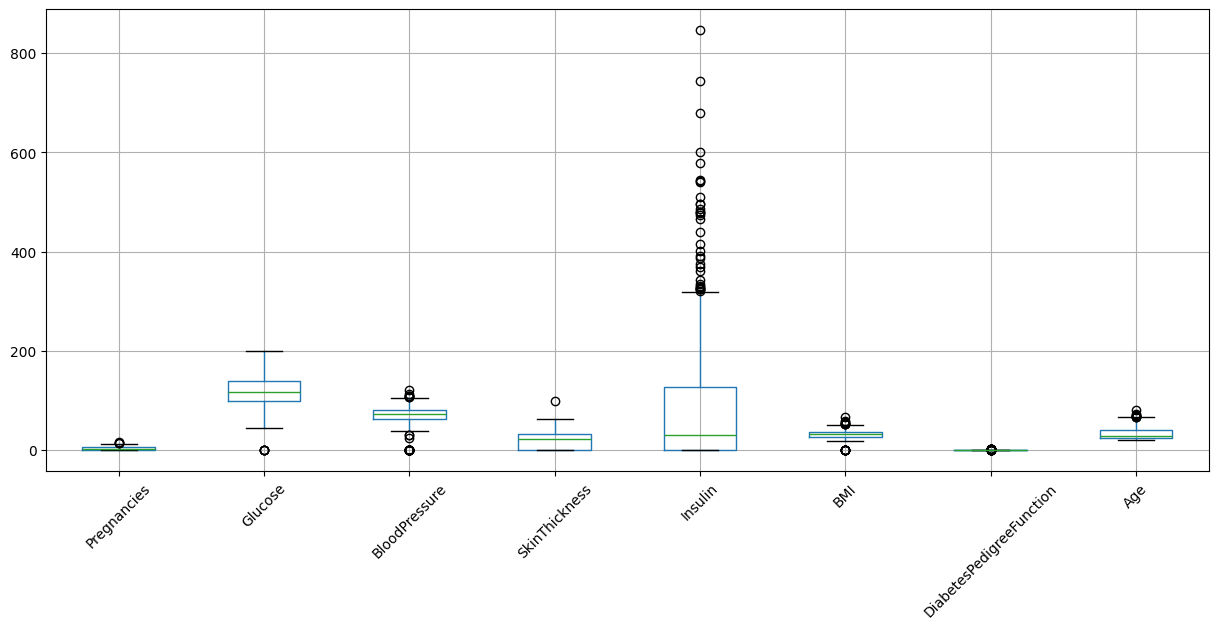

Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64


In [81]:
# 1. Histograms
diabetes_df[col_names].hist(figsize=(15,10))
plt.show()

# 2. Boxplots
diabetes_df[col_names].boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

# 3. Skewness
print(diabetes_df[col_names].skew())

In [82]:
# function to check the count of invalid zeroes

def sum_zeroes():
       for col in col_names:
              print(col, (diabetes_df[col] == 0).sum())
sum_zeroes()

Pregnancies 111
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11
DiabetesPedigreeFunction 0
Age 0


### Distribution Analysis:

#### Pregnancies

Positively (right) skewed.

Most patients have between 0 and 5 pregnancies.

Contains a few high values (outliers).

#### Glucose

Roughly bell-shaped and close to a normal distribution.
Slight right skew.
Contains a few zero values that are medically unrealistic.

#### BloodPressure

Approximately normally distributed.
A few outliers are present.
Contains some zero values that should be treated as missing.

#### SkinThickness

Moderately right-skewed.
Large number of low and zero values.
Several outliers are present.

#### Insulin

Highly right-skewed.
Contains many extreme outliers.
Large number of zero values.
Mean would be heavily influenced by outliers.

#### BMI

Fairly close to a normal distribution.
Slight right skew.
Few outliers.

#### DiabetesPedigreeFunction

Strongly right-skewed.
Most observations are concentrated below 1.
Several extreme values present.

#### Age

Right-skewed.
Majority of patients are younger than 40.
Some older-age outliers exist.

### Observation:

Histogram and boxplot analysis showed that Glucose, BloodPressure, and BMI are approximately normally distributed, while Pregnancies, SkinThickness, Insulin, DiabetesPedigreeFunction, and Age exhibit positive skewness. Insulin contains a large number of extreme outliers. Therefore, median imputation can be used to replace medically invalid zero values, as it is more robust to skewed distributions and outliers than mean imputation.

In [83]:
# using SimpleImputer for replacing 0's

cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI']

# Replace zeros with NaN
diabetes_df[cols] = diabetes_df[cols].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')

diabetes_df[cols] = imputer.fit_transform(diabetes_df[cols])

In [84]:
# validating invalid zero count after imputation
sum_zeroes()

Pregnancies 111
Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0
DiabetesPedigreeFunction 0
Age 0


Zeroes for pregnancies are acceptable not an invalid case

## correlation heatmap

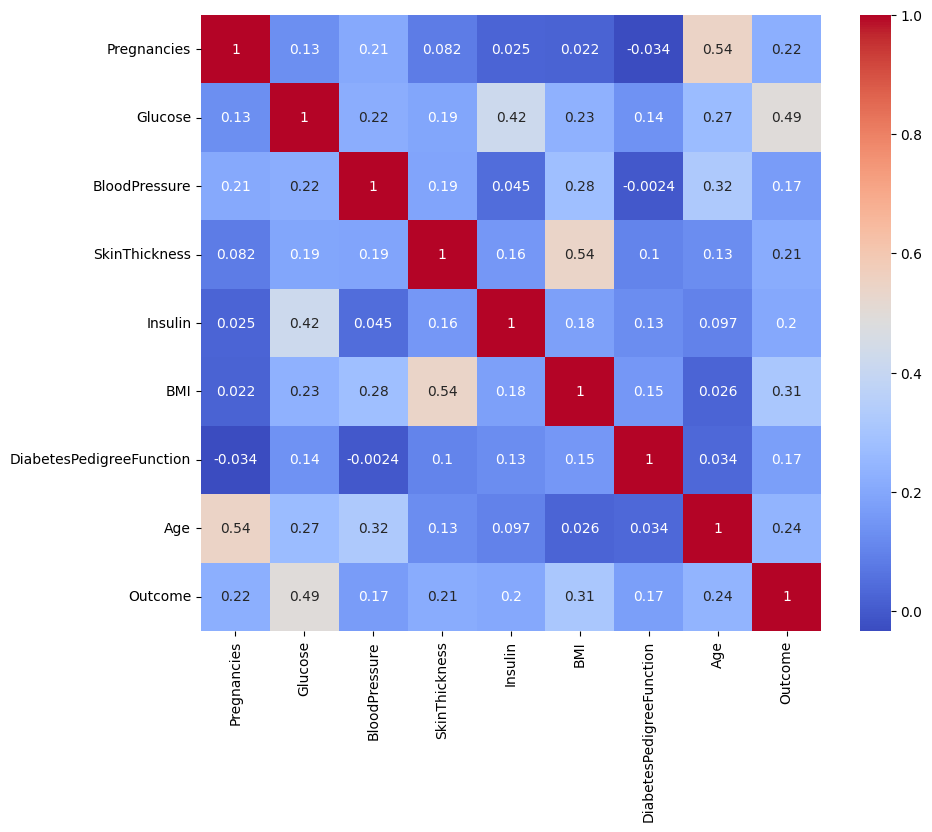

In [85]:

plt.figure(figsize=(10,8))
sns.heatmap(diabetes_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

Observation:

Glucose  has the strongest correlation with Outcome.

BMI, Age and SkinThickness show moderate correlation.

## Step 5: Define Features and Target Variable

In [86]:
X = diabetes_df.drop('Outcome', axis =1)
Y = diabetes_df['Outcome']

In [87]:
# train test split

X_train , X_test , Y_train, Y_test = train_test_split(X,Y,test_size= 0.2,random_state=42)

Think of fit() as:

"Learn the rules."

Think of transform() as:

"Apply the learned rules."

In [88]:
# feature scaling -- important for logistic regression

scaler = StandardScaler()

# Learn + Apply
X_train = scaler.fit_transform(X_train)

# Only Apply
X_test = scaler.transform(X_test)

Why do we use fit_transform() on training data and only transform() on test data?

The scaler learns the mean and standard deviation from the training data using fit(). These learned parameters are then applied to both the training and test sets. No separate learning(fit) for test data. Test data uses the same mean and std from training.

If you fit on the test data, you are allowing information from the test set to influence preprocessing.
The test data should never be allowed to teach the scaler anything. It should only be processed using the rules learned from the training data.

The model is supposed to be evaluated on completely unseen data.

## Step 6: Model Building 

In [89]:
log_reg = LogisticRegression()

log_reg.fit(X_train,Y_train)

y_pred = log_reg.predict(X_test)


## Step 7: Model Evaluation 

#### Accuracy

In [90]:
# Calculate accuracy score

accuracy = accuracy_score(Y_test,y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.7532467532467533


confusion matrix

Confusion Matrix:



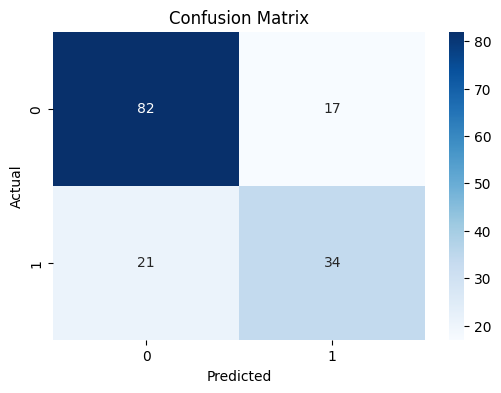

In [91]:
# Create confusion matrix

cm = confusion_matrix(Y_test, y_pred)

print("Confusion Matrix:\n")

# Visualize confusion matrix
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


Classification Report

In [92]:
# Print classification report

report = classification_report(Y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



Non-Diabetic Patients (Class 0):

When the model predicts "Non-Diabetic", it is correct 80% of the time.
It successfully identifies 83% of actual non-diabetic patients.

Diabetic Patients (Class 1):

When the model predicts "Diabetic", it is correct 67% of the time.
It identifies only 62% of actual diabetic patients.



In [93]:
scores = cross_val_score(
    log_reg,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean CV Score:", scores.mean())

[0.73170732 0.81300813 0.75609756 0.74796748 0.79508197]
Mean CV Score: 0.7687724910035986


Hyperparameter Tuning

In [94]:
param_grid = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear','lbfgs']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,Y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'solver': 'liblinear'}
0.7687724910035986


Evaluate the tuned model on the test set:

In [95]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

test_accuracy = accuracy_score(Y_test, y_pred_best)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7532467532467533


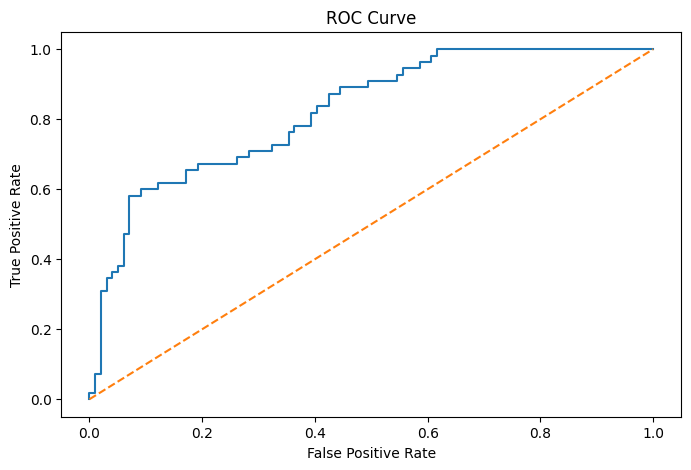

AUC Score: 0.82277318640955


In [96]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc = roc_auc_score(Y_test, y_prob)

print("AUC Score:", auc)

The model achieved an AUC score of 0.82, indicating good discrimination between diabetic and non-diabetic patients.

Feature Importance

In [97]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

                    Feature  Coefficient
1                   Glucose     1.100750
5                       BMI     0.686856
7                       Age     0.390974
0               Pregnancies     0.222399
6  DiabetesPedigreeFunction     0.203486
3             SkinThickness     0.067853
4                   Insulin    -0.138229
2             BloodPressure    -0.151057


### Comparing with Random Forest

In [98]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

In [99]:
rf_acc = accuracy_score(Y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7337662337662337


In [100]:
print(classification_report(Y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [101]:
rf_cv = cross_val_score(
    rf,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy'
)

print("RF Mean CV Score:", rf_cv.mean())

RF Mean CV Score: 0.7785285885645742


In [102]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, Y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.7785285885645742


In [103]:
best_model_RF = grid_rf.best_estimator_

In [104]:
# Random Forest
rf_prob = best_model_RF.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(Y_test, rf_prob)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.8340679522497705


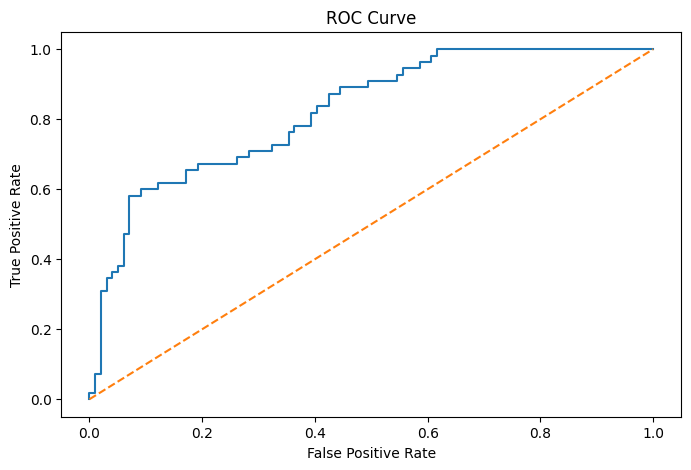

AUC Score: 0.82277318640955


In [105]:

rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc = roc_auc_score(Y_test, y_prob)

print("AUC Score:", auc)

In [106]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model_RF.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

print(rf_importance)

                    Feature  Importance
1                   Glucose    0.263453
5                       BMI    0.164118
7                       Age    0.134927
6  DiabetesPedigreeFunction    0.121819
4                   Insulin    0.089248
2             BloodPressure    0.084062
3             SkinThickness    0.072432
0               Pregnancies    0.069942


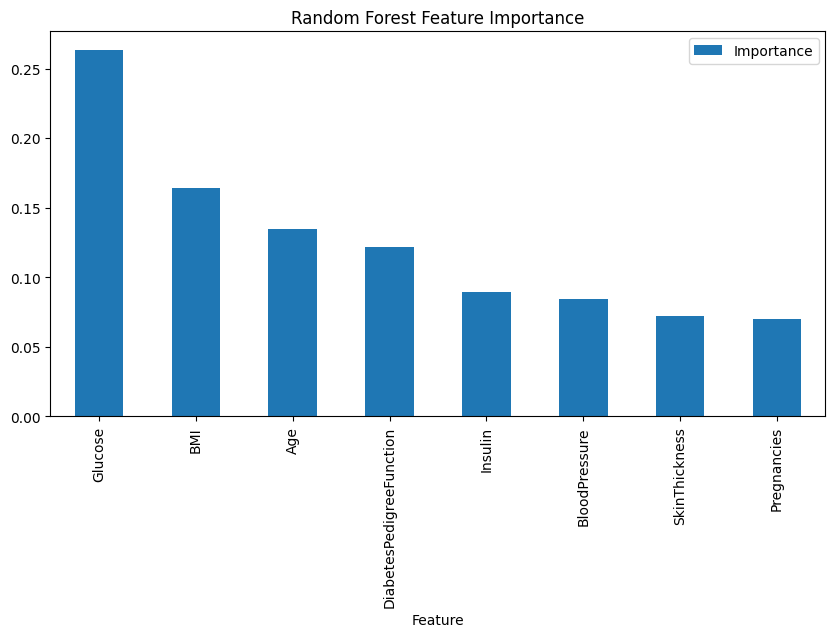

In [107]:
rf_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title('Random Forest Feature Importance')
plt.show()

### Conclusion:

This project developed machine learning models to predict diabetes using the Pima Indians Diabetes Dataset. Data preprocessing included exploratory data analysis, treatment of medically invalid zero values using median imputation, and feature scaling using StandardScaler. Logistic Regression and Random Forest classifiers were trained and evaluated.

Logistic Regression achieved a test accuracy of 75.0% and a cross-validation accuracy of 76.88%, making it the best-performing model based on classification accuracy. Random Forest achieved a test accuracy of 73.38%, a cross-validation accuracy of 77.85%, and an AUC score of 0.834, demonstrating strong discriminatory power across decision thresholds.

Feature importance analysis revealed that Glucose, BMI, and Age were the most influential predictors of diabetes across both models. These findings align with known clinical risk factors for diabetes.

Overall, Logistic Regression provided the best balance of predictive performance and interpretability, while Random Forest offered deeper insight into non-linear feature relationships and achieved strong AUC performance.